# CS5480: Lightweight QA Evaluation with FLAN-T5

## Problem Overview
Large Language Models often hallucinate because they optimize for plausible text rather than factual correctness. This notebook establishes a closed-book baseline for question answering, which will later be compared against retrieval-augmented approaches.

The goal is to measure how well a model can answer questions without external context.

### 1. Imports

In [1]:
!pip install pandas numpy transformers rank-bm25 sentence-transformers

import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rank_bm25 import BM25Okapi
from collections import Counter
from sentence_transformers import SentenceTransformer

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached rank_bm25-0.2.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-win_amd64.whl.metadata (2.4 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-a

c:\Users\Dyson\5480 Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Description
The dataset consists of:
- `question`: input query
- `short_answers`: ground truth answer
- `long_answers`:

This format enables straightforward evaluation using exact string matching and token overlap metrics.

### 2. Load Dataset Function

In [3]:
df = pd.read_csv("Natural-Questions-Filtered.csv")

QUESTIONS = df["question"].tolist()
GROUND_TRUTH = df["short_answers"].tolist()
CORPUS = df["long_answers"].tolist()

### 3. Load Model

In [4]:
model_name = "google/flan-t5-small"
TOKENIZER = AutoTokenizer.from_pretrained(model_name)
MODEL = AutoModelForSeq2SeqLM.from_pretrained(model_name)

c:\Users\Dyson\5480 Project\.venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dyson\.cache\huggingface\hub\models--google--flan-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 190/190 [00:00<00:00, 10800.39it/s]
[transformers] The tied weights mapping and 

### 4. Define Analysis Functions

In [5]:
def generate_answer(question):
    prompt = f"Answer the question: {question}"

    inputs = TOKENIZER(prompt, return_tensors="pt", truncation=True)
    outputs = MODEL.generate(**inputs, max_length=64)

    return TOKENIZER.decode(outputs[0], skip_special_tokens=True)

def exact_match(pred, truth):
    return int(pred.strip().lower() == truth.strip().lower())

def f1_score(pred, truth):
    pred_tokens = pred.lower().split()
    truth_tokens = truth.lower().split()

    pred_counts = Counter(pred_tokens)
    truth_counts = Counter(truth_tokens)

    common = sum((pred_counts & truth_counts).values())

    if common == 0:
        return 0.0

    precision = common / len(pred_tokens)
    recall = common / len(truth_tokens)

    return 2 * (precision * recall) / (precision + recall)

### 5. Define Experiment Loop

In [6]:
def run_experiment(retrieve_fn=None, k=3, limit=100):
    em_scores, f1_scores = [], []

    for i in range(min(limit, len(QUESTIONS))):
        q = QUESTIONS[i]
        truth = GROUND_TRUTH[i]

        # retrieval step
        if retrieve_fn is not None:
            contexts = retrieve_fn(q, k)
            context_str = " ".join(contexts)
            prompt = f"Answer the question using the context:\n{context_str}\n\nQuestion: {q}"
        else:
            prompt = f"Answer the question: {q}"

        # generation
        inputs = TOKENIZER(prompt, return_tensors="pt", truncation=True)
        outputs = MODEL.generate(**inputs, max_length=64)
        pred = TOKENIZER.decode(outputs[0], skip_special_tokens=True)

        # evaluation
        em_scores.append(exact_match(pred, truth))
        f1_scores.append(f1_score(pred, truth))

    return np.mean(em_scores), np.mean(f1_scores)

### 6. Find Baseline Performance
We will identify the baseline performance by prompting our model with no regression techniques applied. This way, we can determine if BM25, dense, or hybrid retrieval actually improve model performance.

In [7]:
print("Running baseline...")
em, f1 = run_experiment()

print("\n=== BASELINE RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running baseline...

=== BASELINE RESULTS ===
Exact Match Score: 0.0200
F1 Score: 0.0670


### 7. Find BM25 Performance

**First, we'll build an index for the answer corpus**

In [8]:
TOKENIZED_CORPUS = [doc.split() for doc in CORPUS]
BM25 = BM25Okapi(TOKENIZED_CORPUS)

**Then, we'll define the retrieval function**

In [9]:
def bm25_retrieve(query, k=3):
    tokenized_query = query.split()

    scores = BM25.get_scores(tokenized_query)
    top_k_idx = np.argsort(scores)[-k:][::-1]

    return [CORPUS[i] for i in top_k_idx]

**Finally, we find the BM25 performance.**

In [10]:
print("Running BM25 experiment...")
em, f1 = run_experiment(retrieve_fn=bm25_retrieve)

print("\n=== BM25 RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running BM25 experiment...

=== BM25 RESULTS ===
Exact Match Score: 0.0300
F1 Score: 0.0879


### 8. Find Dense Retrieval Performance

**First, we build the embeddings for dense retrieval**

In [11]:
EMBED_MODEL = SentenceTransformer("all-MiniLM-L6-v2")

CORPUS_EMBEDDINGS = EMBED_MODEL.encode(
    CORPUS,
    batch_size=32,
    convert_to_numpy=True
)

c:\Users\Dyson\5480 Project\.venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dyson\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10047.76it/s]


**Then, we define the retrieval function**

In [12]:
def dense_retrieve(query, k=3):
    query_emb = EMBED_MODEL.encode(query, convert_to_numpy=True)

    scores = np.dot(CORPUS_EMBEDDINGS, query_emb)
    top_k_idx = np.argsort(scores)[-k:][::-1]

    return [CORPUS[i] for i in top_k_idx]

**Finally, we'll run the experiment**

In [13]:
print("Running dense experiment...")
em, f1 = run_experiment(retrieve_fn=dense_retrieve)

print("\n=== DENSE RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running dense experiment...

=== DENSE RESULTS ===
Exact Match Score: 0.1900
F1 Score: 0.2814


### 9. Find Hybrid Retrieval Performance

**First we need methods to get the BM25 and Dense scores**

In [14]:
def bm25_scores(query):
    tokenized_query = query.split()
    return BM25.get_scores(tokenized_query)

def dense_scores(query):
    query_emb = EMBED_MODEL.encode(query, convert_to_numpy=True, normalize_embeddings=True)
    return np.dot(CORPUS_EMBEDDINGS, query_emb)

**Next, let's define our hybrid retrieval function**

In [15]:
def hybrid_retrieve(query, k=3, alpha=0.5):
    bm25 = bm25_scores(query)
    dense = dense_scores(query)

    # normalize scores to [0, 1]
    bm25 = (bm25 - bm25.min()) / (bm25.max() - bm25.min() + 1e-8)
    dense = (dense - dense.min()) / (dense.max() - dense.min() + 1e-8)

    # combine scores
    combined = alpha * dense + (1 - alpha) * bm25

    top_k_idx = np.argsort(combined)[-k:][::-1]

    return [CORPUS[i] for i in top_k_idx]

**And finally, let's find our hybrid results**

In [16]:
print("Running hybrid experiment...")
em, f1 = run_experiment(retrieve_fn=hybrid_retrieve)

print("\n=== HYBRID RESULTS ===")
print(f"Exact Match Score: {em:.4f}")
print(f"F1 Score: {f1:.4f}")

Running hybrid experiment...

=== HYBRID RESULTS ===
Exact Match Score: 0.0700
F1 Score: 0.1397


**Comparing different alpha values**

In [17]:
for a in [0.2, 0.5, 0.8]:
    print(f"\nAlpha = {a}")
    em, f1 = run_experiment(lambda q, k: hybrid_retrieve(q, k, alpha=a))
    print(f"EM: {em:.4f}, F1: {f1:.4f}")


Alpha = 0.2
EM: 0.0300, F1: 0.0787

Alpha = 0.5
EM: 0.0700, F1: 0.1397

Alpha = 0.8
EM: 0.1700, F1: 0.2374


### 10. Comparison and Analysis

In [18]:
import pandas as pd

data = {
    "Method": [
        "Baseline",
        "BM25",
        "Dense",
        "Hybrid (a=0.2)",
        "Hybrid (a=0.5)",
        "Hybrid (a=0.8)"
    ],
    "EM": [0.02, 0.03, 0.19, 0.03, 0.07, 0.17],
    "F1": [0.07, 0.088, 0.281, 0.079, 0.140, 0.237]
}

df_results = pd.DataFrame(data)
print(df_results)

           Method    EM     F1
0        Baseline  0.02  0.070
1            BM25  0.03  0.088
2           Dense  0.19  0.281
3  Hybrid (a=0.2)  0.03  0.079
4  Hybrid (a=0.5)  0.07  0.140
5  Hybrid (a=0.8)  0.17  0.237


  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl (1.6 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ----- ---------------------------------- 1/7 [pillow]
   ----

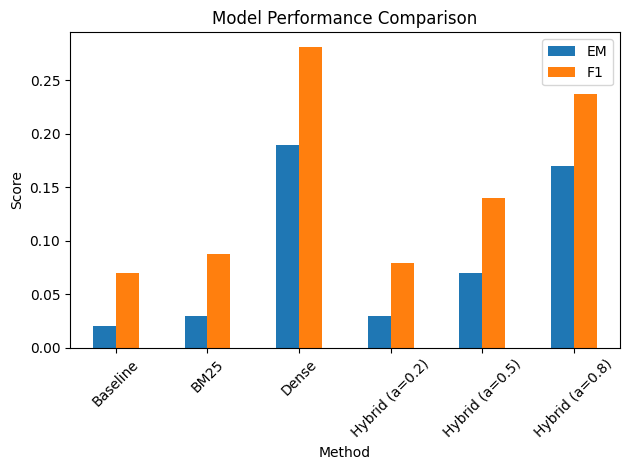

In [20]:
!pip install matplotlib

import matplotlib.pyplot as plt

df_results.set_index("Method")[["EM", "F1"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

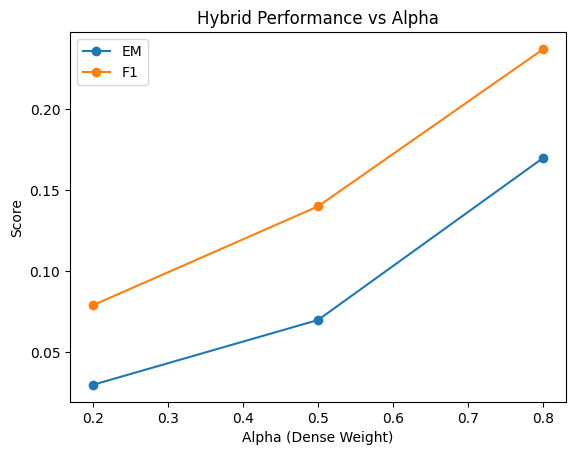

In [21]:
hybrid_df = df_results[df_results["Method"].str.contains("Hybrid")].copy()
hybrid_df["alpha"] = [0.2, 0.5, 0.8]

plt.plot(hybrid_df["alpha"], hybrid_df["EM"], marker='o', label="EM")
plt.plot(hybrid_df["alpha"], hybrid_df["F1"], marker='o', label="F1")

plt.title("Hybrid Performance vs Alpha")
plt.xlabel("Alpha (Dense Weight)")
plt.ylabel("Score")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

for method in df_k["Method"].unique():
    subset = df_k[df_k["Method"] == method]
    
    # F1 (solid)
    plt.plot(subset["k"], subset["F1"],
             marker='o', linestyle='-',
             label=f"{method} - F1")
    
    # EM (dashed)
    plt.plot(subset["k"], subset["EM"],
             marker='o', linestyle='--',
             label=f"{method} - EM")

plt.title("QA Performance vs k (Retrieval Depth)")
plt.xlabel("k")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()